# Sentiment Prediction Using LSTM / GRU

This notebook builds an RNN-based sentiment classifier for product reviews.

Goal:
- Use a suitable review dataset
- Train an LSTM or GRU model
- Predict sentiment on new reviews

## 1. Import Required Libraries

In [34]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout, SpatialDropout1D

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.18.0


In [35]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Load and Explore the Dataset

We use the local IMDB Movie Reviews CSV file: `IMDB_Dataset.csv`.
- `sentiment` contains `positive` / `negative`
- We convert it to `label` where `1 = positive`, `0 = negative`

In [36]:
df = pd.read_csv('IMDB-Dataset.csv')

In [37]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [38]:
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [39]:
df = df.drop("sentiment", axis=1)
df.head()

,review,label
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


## 3. Preprocess and Prepare Data

We clean text by:
- converting to lowercase
- removing non-alphanumeric characters
- removing extra spaces
- dropping missing values

In [40]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df = df.dropna(subset=['review', 'label']).copy()
df['label'] = df['label'].astype(int)
df['clean_review'] = df['review'].apply(clean_text)

print(df[['review', 'clean_review', 'label']].head())

                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                        clean_review  label  
0  one of the other reviewers has mentioned that ...      1  
1  a wonderful little production br br the filmin...      1  
2  i thought this was a wonderful way to spend ti...      1  
3  basically there s a family where a little boy ...      0  
4  petter mattei s love in the time of money is a...      1  


In [41]:
df

,review,label,clean_review
0,One of the other reviewers has mentioned that ...,1,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,1,a wonderful little production br br the filmin...
2,I thought this was a wonderful way to spend ti...,1,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,0,basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter mattei s love in the time of money is a...
...,...,...,...
49995,I thought this movie did a down right good job...,1,i thought this movie did a down right good job...
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",0,bad plot bad dialogue bad acting idiotic direc...
49997,I am a Catholic taught in parochial elementary...,0,i am a catholic taught in parochial elementary...
49998,I'm going to have to disagree with the previou...,0,i m going to have to disagree with the previou...


In [42]:
df1 = df.drop("review",axis=1)
df1

,label,clean_review
0,1,one of the other reviewers has mentioned that ...
1,1,a wonderful little production br br the filmin...
2,1,i thought this was a wonderful way to spend ti...
3,0,basically there s a family where a little boy ...
4,1,petter mattei s love in the time of money is a...
...,...,...
49995,1,i thought this movie did a down right good job...
49996,0,bad plot bad dialogue bad acting idiotic direc...
49997,0,i am a catholic taught in parochial elementary...
49998,0,i m going to have to disagree with the previou...


# 4. Tokenize and Vectorize Text Data

In [43]:
VOCAB_SIZE = 10000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_review'])

sequences = tokenizer.texts_to_sequences(df['clean_review'])
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = df1['label'].values

print('Feature shape:', X.shape)
print('Label shape:', y.shape)

Feature shape: (50000, 200)
Label shape: (50000,)


## 5. Split Data into Train and Test Sets

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 6. Build LSTM Model Architecture

Set `MODEL_TYPE` to `'LSTM'` or `'GRU'`.

In [45]:
MODEL_TYPE = 'LSTM'  # Change to 'GRU' to use GRU model

recurrent_layer = LSTM(64, dropout=0.2, recurrent_dropout=0.2)
if MODEL_TYPE.upper() == 'GRU':
    recurrent_layer = GRU(64, dropout=0.2, recurrent_dropout=0.2)

model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=64, input_length=MAX_LEN),
    SpatialDropout1D(0.2),
    recurrent_layer,
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

C:\Users\Rohan\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


## 7. Compile the Model

In [46]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('Model compiled successfully.')

Model compiled successfully.


## 8. Train the Model

In [47]:
EPOCHS = 3
BATCH_SIZE = 128

history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

Epoch 1/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 32s 120ms/step - accuracy: 0.5249 - loss: 0.6889 - val_accuracy: 0.6926 - val_loss: 0.6096
Epoch 2/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 31s 122ms/step - accuracy: 0.6615 - loss: 0.6336 - val_accuracy: 0.5600 - val_loss: 0.6710
Epoch 3/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 31s 123ms/step - accuracy: 0.6416 - loss: 0.6336 - val_accuracy: 0.7315 - val_loss: 0.5750


## 9. Evaluate Model Performance

In [50]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Accuracy: {test_acc:.4f}')

y_prob = model.predict(X_test, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)

print('\nClassification Report:')
print(classification_report(y_test, y_pred, digits=4))

print('Accuracy :', round(accuracy_score(y_test, y_pred), 4))
print('Precision:', round(precision_score(y_test, y_pred), 4))
print('Recall   :', round(recall_score(y_test, y_pred), 4))
print('F1 Score :', round(f1_score(y_test, y_pred), 4))

Test Accuracy: 0.7355

Classification Report:
              precision    recall  f1-score   support

           0     0.7356    0.7289    0.7322      4961
           1     0.7354    0.7420    0.7387      5039

    accuracy                         0.7355     10000
   macro avg     0.7355    0.7354    0.7355     10000
weighted avg     0.7355    0.7355    0.7355     10000

Accuracy : 0.7355
Precision: 0.7354
Recall   : 0.742
F1 Score : 0.7387


## 10. Make Predictions on New Reviews

In [49]:
def predict_review_sentiment(review_text):
    cleaned = clean_text(review_text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob = float(model.predict(padded, verbose=0)[0][0])
    label = 'Positive' if prob >= 0.5 else 'Negative'
    return label, prob

new_reviews = ["One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side."
,"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ruins all the film! I expected to see a BOOGEYMAN similar movie, and instead i watched a drama with some meaningless thriller spots.<br /><br />3 out of 10 just for the well playing parents & descent dialogs. As for the shots with Jake: just ignore them."]

for text in new_reviews:
    label, prob = predict_review_sentiment(text)
    print(f'Review: {text}')
    print(f'Predicted Sentiment: {label} (confidence={prob:.4f})\n')

Review: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to

## 11. Visualize Results

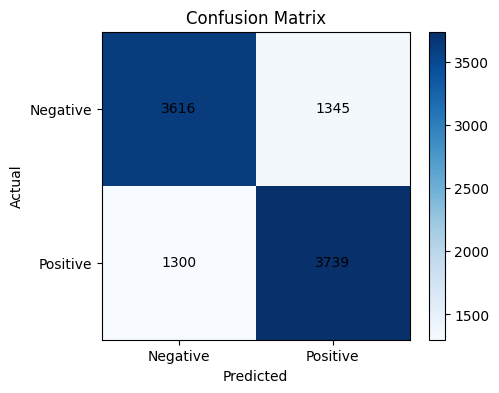

In [51]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.yticks([0, 1], ['Negative', 'Positive'])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.colorbar()
plt.show()